In [34]:
import json
import os
import random
from pathlib import Path

import kagglehub
import pandas as pd
import torch
from torch.utils.data import Subset, DataLoader

from model import SimpleCNNConv3
from src.dataset import TmpCifarDataset, define_transformations
from src.metrics import calculate_confusion_matrix, calculate_per_class_accuracy, plot_confusion_matrix
from src.model import SimpleCNN

In [35]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


In [36]:
experiment_dir = Path("../experiments/65")

with open(experiment_dir / "config.json", encoding="utf-8") as file:
    config_json = json.load(file)

    seed = int(config_json["seed"])

    batch_size = int(config_json["data"]["batch_size"])
    augmentation = config_json["data"]["augmentation"]

    model = config_json["model"]["name"]
    dropout = config_json["model"]["dropout"]

    learning_rate = float(config_json["training"]["learning_rate"])
    weight_decay = float(config_json["training"]["weight_decay"])
    scheduler_config = config_json["training"]["scheduler"]
    epochs = int(config_json["training"]["epochs"])

In [37]:
with open("../configs/data_stats.json", encoding="utf-8") as file:
    stats = json.load(file)
    mean = stats["mean"]
    std = stats["std"]

In [38]:
with open("../configs/data_split.json", encoding="utf-8") as file:
    split = json.load(file)

In [39]:
random.seed(seed)
torch.manual_seed(seed)

In [40]:
dataset_path = kagglehub.competition_download('cifar-10')
labels_path = os.path.join(dataset_path, 'trainLabels.csv')
train_path = os.path.join(dataset_path, 'train')

In [41]:
cifar_pd = pd.read_csv("../data/processed/cifar10_metadata.csv")

In [42]:
train_transform, val_transform = define_transformations(augmentation, mean, std)

# Reuse the exact indices used for the statistics split.
train_dataset = TmpCifarDataset(train_path, cifar_pd, transform=train_transform)
val_dataset = TmpCifarDataset(train_path, cifar_pd, transform=val_transform)
train_subset = Subset(train_dataset, split["train_indices"])
val_subset = Subset(val_dataset, split["val_indices"])

train_data_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_data_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

In [43]:
num_classes = len(train_dataset.labels.value_counts())
model = SimpleCNNConv3(
    num_classes=num_classes,
    dropout=dropout,
).to(device)

model.load_state_dict(
    torch.load(experiment_dir / "model.pt", map_location=device)
)
model.eval()

SimpleCNNConv3(
  (conv_block1): CNNBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (conv_block2): CNNBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (conv_block3): CNNBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=1

In [44]:
# per-class accuracy
class_names = (
    cifar_pd[["target", "label"]]
    .drop_duplicates()
    .sort_values("target")["label"]
    .tolist()
)

per_class_accuracy = calculate_per_class_accuracy(
    model,
    val_data_loader,
    class_names,
    device,
)

print(pd.DataFrame(
    per_class_accuracy.items(),
    columns=["Class", "Accuracy (%)"],
).sort_values("Accuracy (%)"))

        Class  Accuracy (%)
7         cat     76.854220
8         dog     80.440415
4        bird     84.820240
2        deer     87.427746
9    airplane     90.637720
5       horse     90.782123
1       truck     91.281374
0        frog     92.682927
6        ship     92.965517
3  automobile     94.518717


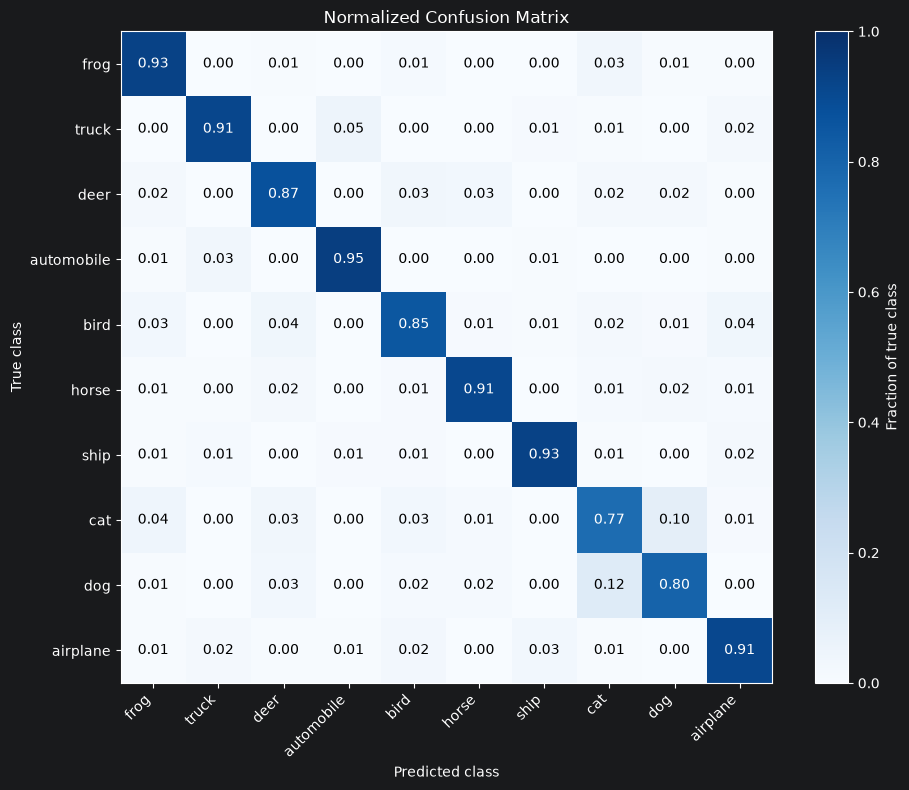

,frog,truck,deer,automobile,bird,horse,ship,cat,dog,airplane
frog,760,0,6,3,12,1,2,26,6,4
truck,1,691,0,36,1,2,6,5,1,14
deer,14,1,605,1,24,19,1,13,11,3
automobile,4,25,0,707,2,1,5,0,1,3
bird,23,0,28,1,637,7,4,16,8,27
horse,4,3,15,0,7,650,1,10,16,10
ship,5,10,2,6,7,1,674,4,1,15
cat,34,3,25,0,22,10,3,601,75,9
dog,5,1,22,0,12,12,2,94,621,3
airplane,4,12,3,4,18,1,22,4,1,668


In [45]:
confusion_matrix = calculate_confusion_matrix(
    model,
    val_data_loader,
    num_classes,
    device,
)

plot_confusion_matrix(confusion_matrix, class_names)

pd.DataFrame(
    confusion_matrix.numpy(),
    index=class_names,
    columns=class_names,
)